# Discovering New EuroLeague Player Roles Using Unsupervised Learning

**Doron and Yuval**

## Research question

Can we find natural EuroLeague player roles directly from playing behavior, without relying
on the traditional position labels (Guard, Forward, Center)?

## Motivation

Modern basketball players often do not fit cleanly into the three traditional positions. A
lot of "forwards" shoot threes like guards, and some "guards" rebound like forwards. We want
to see whether an unsupervised model, given enough statistics about how a player actually
plays, groups players in a way that says more about their real role than their listed
position does.

To keep this honest, we do not give the model the position label at all. We only use
`position` afterwards, to check whether the groups we find line up with the traditional
positions or cut across them.

## Data sources

We are working with three raw tables and one file we produced earlier by combining two of
them:

- **`euroleague_players.csv`** — one row per player, season, and team, with season totals
  (points, rebounds, assists, shooting splits, etc.).
- **`euroleague_points.csv`** — one row per recorded shot or free-throw event, including the
  court coordinates of the attempt.
- **`players_bio.csv`** — one row per player, scraped from the EuroLeague website (height,
  position, nationality, etc.).
- **`merged_euroleague_players.csv`** — the shot-event table enriched with the biography
  columns, produced from the two files above. We treat it as something we can regenerate,
  not as a separate source of information.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")


def find_repo_root(start: Path, markers=("data", "notebooks")) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError(f"Could not find the project root from {start}")


REPO_ROOT = find_repo_root(Path(globals().get("__file__", Path.cwd())))
DATA_RAW = REPO_ROOT / "data" / "raw"
FIG_DIR = REPO_ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

players_df = pd.read_csv(DATA_RAW / "euroleague_players.csv", low_memory=False)
points_df = pd.read_csv(DATA_RAW / "euroleague_points.csv", low_memory=False)
bio_df = pd.read_csv(DATA_RAW / "players_bio.csv", low_memory=False)

print(f"euroleague_players.csv: {players_df.shape[0]:,} rows, {players_df.shape[1]} columns")
print(f"euroleague_points.csv:  {points_df.shape[0]:,} rows, {points_df.shape[1]} columns")
print(f"players_bio.csv:        {bio_df.shape[0]:,} rows, {bio_df.shape[1]} columns")

euroleague_players.csv: 6,307 rows, 50 columns
euroleague_points.csv:  755,145 rows, 24 columns
players_bio.csv:        2,363 rows, 14 columns


## Understanding the data

Before doing anything else, we needed to know what a row actually represents in each table,
and which columns we could use to join them together.

`euroleague_players.csv` has one row per player, per season, per team — a player who changes
teams mid-season gets a separate row for each team. `euroleague_points.csv` has one row per
recorded shot or free-throw attempt during a game, with `coord_x`/`coord_y` marking where on
the court it happened. `players_bio.csv` has one row per player, scraped from the EuroLeague
website, and is where height and traditional position come from.

In [2]:
players_df[["season_player_id", "season_code", "player_id", "player", "team_id",
            "games_played", "minutes", "points", "assists", "total_rebounds"]].sample(
    3, random_state=RANDOM_STATE)

,season_player_id,season_code,player_id,player,team_id,games_played,minutes,points,assists,total_rebounds
1893,E2014_PAWN_GAL,E2014,PAWN,"GONLUM, KEREM",GAL,23,400.6,176,14,105
351,E2009_PBCW_BAR,E2009,PBCW,"BARTON, LUBOS",BAR,1,4.1,4,0,0
1498,E2010_PDHF_OLY,E2010,PDHF,"ERCEG, ZORAN",OLY,16,284.6,94,8,50


In [3]:
points_df[["game_point_id", "game_id", "season_code", "team_id", "player_id", "player",
           "action", "coord_x", "coord_y", "zone"]].sample(3, random_state=RANDOM_STATE)

,game_point_id,game_id,season_code,team_id,player_id,player,action,coord_x,coord_y,zone
593375,E2023_025_526,E2023_025,E2023,RED,P006436,"GIEDRAITIS, ROKAS",Free Throw In,-1,-1,NaN
563713,E2022_157_063,E2022_157,E2022,PAN,P011225,"LEE, PARIS",Missed Two Pointer,18,326,E
259408,E2015_024_271,E2015_024,E2015,BAM,P005460,"HARRIS, ELIAS",Missed Two Pointer,-6,31,A


In [4]:
bio_df[["player_id", "first_name", "last_name", "height_cm", "position", "club_code"]].sample(
    3, random_state=RANDOM_STATE)

,player_id,first_name,last_name,height_cm,position,club_code
1138,PAON,BARISA,KRASIC,203.0,Forward,CIB
1628,P004945,BRANDON,PAUL,193.0,Guard,OLY
1606,PACJ,MANOLIS,PAPAMAKARIOS,190.0,Guard,OLY


`player_id` is the natural key to connect `euroleague_players.csv`/`euroleague_points.csv` to
`players_bio.csv`, since a player keeps the same `player_id` across seasons and teams. For
connecting the two event-and-season tables to each other, we need the combination
`season_code + player_id + team_id`, because using `player_id` alone would merge a player's
different seasons and teams into one group.

## Checking data quality

Before combining the datasets, we checked the identifiers, coverage, and missing values that could affect the analysis.

In [5]:
print("season_player_id is unique:", players_df["season_player_id"].is_unique)
print("game_point_id is unique:", points_df["game_point_id"].is_unique)
print("player_id is unique in players_bio.csv:", bio_df["player_id"].is_unique)
print("season_code + player_id + team_id is unique in euroleague_players.csv:",
      not players_df.duplicated(subset=["season_code", "player_id", "team_id"]).any())

season_player_id is unique: True
game_point_id is unique: True
player_id is unique in players_bio.csv: True
season_code + player_id + team_id is unique in euroleague_players.csv: True


All four identifiers behave the way we need them to, so we can use them directly for joining
without worrying about duplicate rows sneaking in.

In [6]:
seasons_players = set(players_df["season_code"].unique())
seasons_points = set(points_df["season_code"].unique())
print("Seasons in euroleague_players.csv:", len(seasons_players), "-",
      min(seasons_players), "to", max(seasons_players))
print("Seasons in euroleague_points.csv:", len(seasons_points), "-",
      min(seasons_points), "to", max(seasons_points))
print("Same set of seasons in both files:", seasons_players == seasons_points)

Seasons in euroleague_players.csv: 19 - E2007 to E2025
Seasons in euroleague_points.csv: 19 - E2007 to E2025
Same set of seasons in both files: True


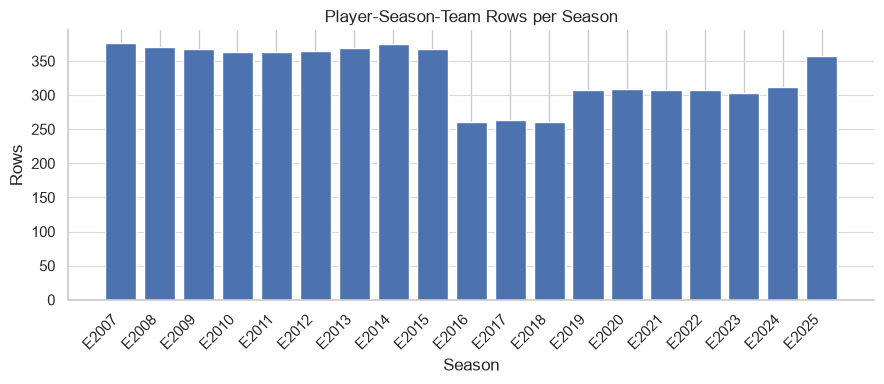

In [7]:
rows_per_season = players_df.groupby("season_code").size()
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(rows_per_season.index, rows_per_season.values, color="#4C72B0")
ax.set_title("Player-Season-Team Rows per Season")
ax.set_xlabel("Season")
ax.set_ylabel("Rows")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.grid(axis="y", color="0.85", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "season_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

Both tables cover the same 19 seasons, `E2007` to `E2025`, with no gaps, and the number of
player-season-team rows per season is fairly stable — a bit higher in the earlier seasons and
lower more recently, but nothing that looks like missing seasons.

In [8]:
zero_minutes = players_df[players_df["minutes"] <= 0]
zero_games = players_df[players_df["games_played"] <= 0]
print(f"Rows with zero or negative minutes: {len(zero_minutes)}")
print(f"Rows with zero or negative games played: {len(zero_games)}")

Rows with zero or negative minutes: 303
Rows with zero or negative games played: 302


In [9]:
has_games = players_df["games_played"] > 0
expected_mpg = players_df.loc[has_games, "minutes"] / players_df.loc[has_games, "games_played"]
mismatch = (players_df.loc[has_games, "minutes_per_game"] - expected_mpg).abs() > 0.01
print(f"Rows where the provided minutes_per_game does not match minutes / games_played "
      f"(tolerance 0.01): {mismatch.sum()} of {has_games.sum()}")
players_df.loc[has_games].loc[mismatch, ["season_player_id", "player", "minutes",
                                          "games_played", "minutes_per_game"]].head(3)

Rows where the provided minutes_per_game does not match minutes / games_played (tolerance 0.01): 462 of 6005


,season_player_id,player,minutes,games_played,minutes_per_game
9,E2012_P003527_CTU,"ABASS, AWUDU",36.8,2,18.38
18,E2022_P012298_OLY,"ABOSI, VENIAMIN",1.4,1,1.43
55,E2018_P004429_OLY,"AGRAVANIS, DIMITRIS",5.2,1,5.25


303 rows have zero or negative minutes and 302 have zero or negative games played — mostly
players who were on a roster but never actually played, so we will need to exclude or handle
these separately once we start building per-minute features.

More importantly, the `minutes_per_game` column that comes with the file does not match
`minutes / games_played` in 462 rows. Since we don't know how that column was computed, we
decided to always derive per-game or per-minute statistics ourselves from the raw totals
(`minutes`, `points`, etc.) instead of trusting the provided per-game columns.

Missing height: 27 of 2363 players
Missing position: 54 of 2363 players


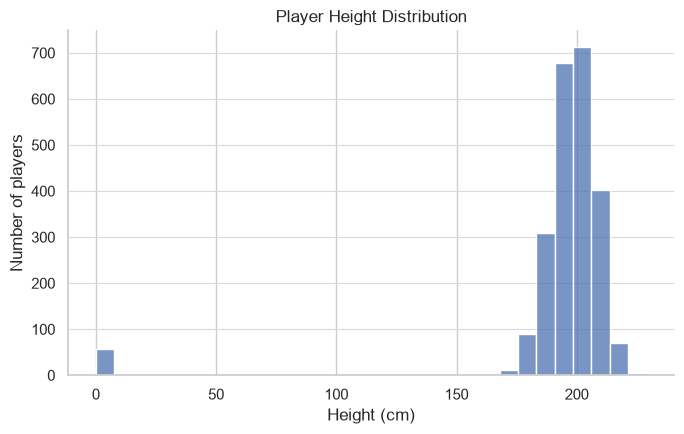

In [10]:
missing_height = bio_df["height_cm"].isna().sum()
missing_position = bio_df["position"].isna().sum()
print(f"Missing height: {missing_height} of {len(bio_df)} players")
print(f"Missing position: {missing_position} of {len(bio_df)} players")

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(bio_df["height_cm"].dropna(), bins=30, color="#4C72B0", ax=ax)
ax.set_title("Player Height Distribution")
ax.set_xlabel("Height (cm)")
ax.set_ylabel("Number of players")
ax.grid(axis="y", color="0.85", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "height_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

27 players are missing height and 54 are missing position, mostly players whose EuroLeague
profile page could not be scraped. Height looks like a plausible feature for later (it has a
normal-looking distribution, roughly 180-210 cm), so we will keep it as a candidate and
decide later whether to drop the players missing it or handle them separately. `position` is
never going to be a model input anyway — we only need it later for comparison, so its missing
values matter less.

In [11]:
action_ids_per_season = points_df.groupby("season_code")["action_id"].nunique()
action_ids_per_season.to_frame("distinct_action_ids")

,distinct_action_ids
season_code,
E2007,7
E2008,10
E2009,10
E2010,10
E2011,10
E2012,10
E2013,10
E2014,10
E2015,7


The set of event types recorded in `euroleague_points.csv` is not the same across all
seasons: `E2007` only has 7 action codes, `E2008`-`E2014` has 10 (including separate codes for
dunks, layups, and blocked shots), `E2015`-`E2016` drops back to 7, and from `E2017` onward
there are only 5 (just made/missed two- and three-point attempts plus free throws). This means
we can't build a "dunk rate" or "blocked-shot rate" feature that covers the whole 2007-2025
range — at best it would only be usable for the `E2008`-`E2014` seasons, so we are leaving
those out of the feature set for now.

## Combining the data

With the three tables understood, the next question was how to join them without losing or
duplicating rows.

In [12]:
players_with_bio = players_df.merge(bio_df, on="player_id", how="left", validate="m:1")
points_with_bio = points_df.merge(bio_df, on="player_id", how="left", validate="m:1")

print(f"euroleague_players.csv: {len(players_df)} rows in, {len(players_with_bio)} rows out")
print(f"euroleague_points.csv:  {len(points_df)} rows in, {len(points_with_bio)} rows out")
print("player_id values with no biography match:",
      (~players_df["player_id"].isin(bio_df["player_id"])).sum(), "(from euroleague_players.csv),",
      (~points_df["player_id"].isin(bio_df["player_id"])).sum(), "(from euroleague_points.csv)")

euroleague_players.csv: 6307 rows in, 6307 rows out
euroleague_points.csv:  755145 rows in, 755145 rows out
player_id values with no biography match: 0 (from euroleague_players.csv), 0 (from euroleague_points.csv)


Joining on `player_id` with `validate="m:1"` confirmed that every player in both tables has
exactly one matching biography row, and the row counts didn't change — so we can safely add
height and position to either table with a plain left join. This is also how
`merged_euroleague_players.csv` (the file we produced earlier) was built: it's just
`euroleague_points.csv` left-joined with `players_bio.csv` on `player_id`. We don't need to
treat it as a separate data source — we can always regenerate it from the two raw files.

In [13]:
season_team_stats = players_df[["season_code", "player_id", "team_id"]].drop_duplicates()
season_team_events = points_df[["season_code", "player_id", "team_id"]].drop_duplicates()

only_in_stats = season_team_stats.merge(season_team_events, on=["season_code", "player_id", "team_id"],
                                         how="left", indicator=True)
only_in_stats = only_in_stats[only_in_stats["_merge"] == "left_only"]
print(f"player-season-team rows in euroleague_players.csv with no matching shot events: "
      f"{len(only_in_stats)} of {len(season_team_stats)}")

player-season-team rows in euroleague_players.csv with no matching shot events: 459 of 6307


459 player-season-team rows in `euroleague_players.csv` have no matching rows at all in
`euroleague_points.csv`. That is a real gap — it means we won't have shot-location features
for those player-seasons — but we are keeping them in the season-level table rather than
dropping them, since they still have valid totals (points, rebounds, etc.). When we build the
combined feature table, these rows will simply end up with missing shot-location features
instead of being removed.

In [14]:
teams_per_player_season = players_df.groupby(["season_code", "player_id"])["team_id"].nunique()
multi_team = teams_per_player_season[teams_per_player_season > 1]
print(f"Player-seasons split across more than one team: {len(multi_team)}")

example_season, example_player = multi_team.index[0]
players_df[(players_df["season_code"] == example_season) &
           (players_df["player_id"] == example_player)][
    ["season_player_id", "season_code", "player", "team_id", "games_played", "minutes"]]

Player-seasons split across more than one team: 58


,season_player_id,season_code,player,team_id,games_played,minutes
5773,E2007_PASG_CSK,E2007,"VAN DEN SPIEGEL, TOMAS",CSK,8,79.4
5774,E2007_PASG_SOP,E2007,"VAN DEN SPIEGEL, TOMAS",SOP,10,237.8


58 player-seasons are split across two teams (a mid-season transfer), each with its own row.
We are keeping these as separate rows rather than merging them, since the whole point of using
`season_code + player_id + team_id` as the key is to let a player's role differ by team.

One more thing worth noting: `players_bio.csv` also has `club_code`/`club_name`, which is the
player's club at the time the page was scraped — not their team in a given season. We use
`team_id` from `euroleague_players.csv`/`euroleague_points.csv` for anything historical, and
only use the biography table for things that don't change with time, like height.

## Understanding shot coordinates

`euroleague_points.csv` gives us `coord_x`/`coord_y` for every recorded attempt, which is
potentially a rich source of playing-style information — where on the court a player likes to
shoot from. Before we can turn that into features, we need to know what the numbers mean. We could not find a documented definition of the coordinate system in the dataset source, so we interpreted it using the spatial distribution of the shots.

The first thing we noticed is that free throws (`action_id == "FTM"`) all carry the exact same
coordinate, `(-1, -1)`, for all 140,926 free-throw rows. That makes sense — a free throw is
always taken from the same spot, so there's nothing to record — but it also means this value
is a placeholder, not a real location, so we excluded free throws from anything spatial and
kept only genuine field-goal attempts (makes and misses, two- and three-point).

In [15]:
SHOT_ACTION_IDS = ["2FGA", "2FGAB", "2FGM", "3FGA", "3FGAB", "3FGM", "DUNK", "LAYUPATT", "LAYUPMD"]
TWO_PT_IDS = ["2FGA", "2FGAB", "2FGM", "DUNK", "LAYUPATT", "LAYUPMD"]
THREE_PT_IDS = ["3FGA", "3FGAB", "3FGM"]

shots = points_df[points_df["action_id"].isin(SHOT_ACTION_IDS)].copy()
print(f"Shot attempts (field-goal makes and misses): {len(shots):,} of {len(points_df):,} rows")
print(f"Missing coordinates among shot attempts: {shots[['coord_x', 'coord_y']].isna().any(axis=1).sum()}")

shots["shot_type"] = np.where(shots["action_id"].isin(THREE_PT_IDS), "Three-point", "Two-point")

Shot attempts (field-goal makes and misses): 614,219 of 755,145 rows
Missing coordinates among shot attempts: 0


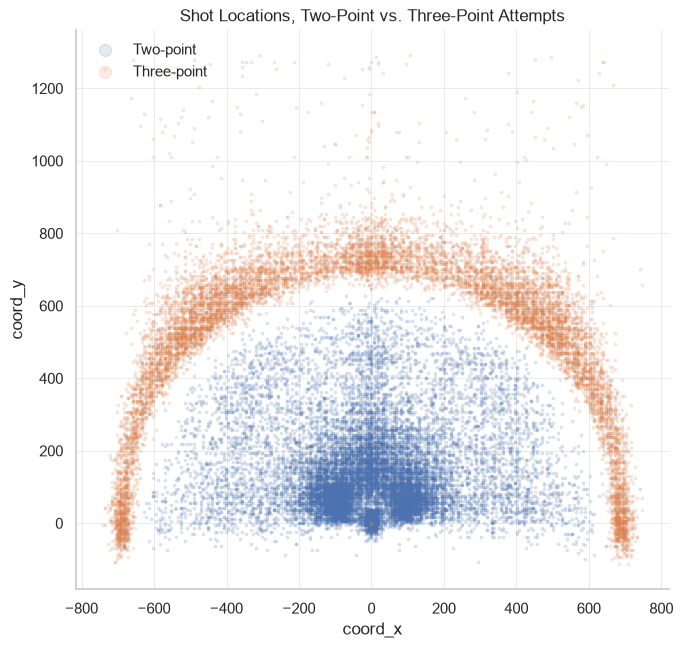

In [16]:
sample = shots.sample(min(30000, len(shots)), random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(7, 8))
for shot_type, color in [("Two-point", "#4C72B0"), ("Three-point", "#DD8452")]:
    sub = sample[sample["shot_type"] == shot_type]
    ax.scatter(sub["coord_x"], sub["coord_y"], s=3, alpha=0.15, color=color, label=shot_type)
ax.set_aspect("equal", adjustable="box")
ax.set_title("Shot Locations, Two-Point vs. Three-Point Attempts")
ax.set_xlabel("coord_x")
ax.set_ylabel("coord_y")
ax.legend(markerscale=5, frameon=False)
ax.grid(color="0.9", linewidth=0.6)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "shot_locations_2pt_3pt.png", dpi=150, bbox_inches="tight")
plt.show()

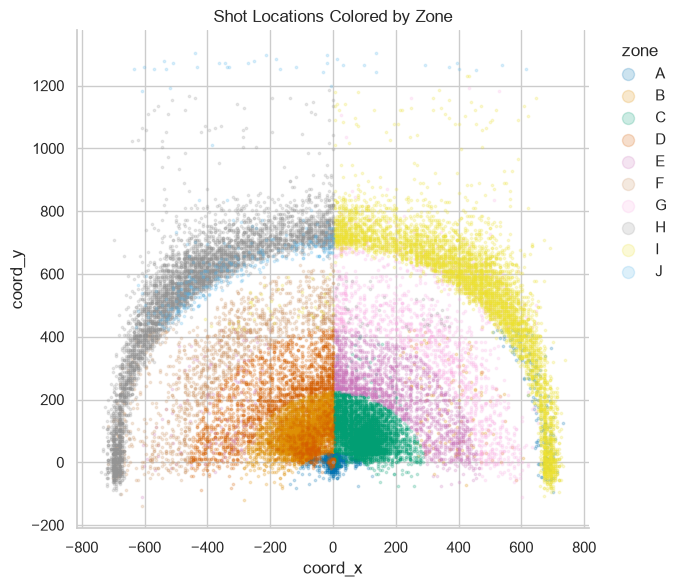

In [17]:
fig, ax = plt.subplots(figsize=(7, 8))
zone_sample = shots.dropna(subset=["zone"]).sample(min(30000, shots["zone"].notna().sum()),
                                                     random_state=RANDOM_STATE)
palette = dict(zip(sorted(zone_sample["zone"].unique()),
                    sns.color_palette("colorblind", n_colors=zone_sample["zone"].nunique())))
for z, sub in zone_sample.groupby("zone"):
    ax.scatter(sub["coord_x"], sub["coord_y"], s=3, alpha=0.2, color=palette[z], label=z)
ax.set_aspect("equal", adjustable="box")
ax.set_title("Shot Locations Colored by Zone")
ax.set_xlabel("coord_x")
ax.set_ylabel("coord_y")
ax.legend(title="zone", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=5)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "shot_locations_by_zone.png", dpi=150, bbox_inches="tight")
plt.show()

Both plots show a single half-court, not two mirrored halves: two-point attempts form a dense
fan close to one point near the bottom of the plot, and three-point attempts form a clear arc
farther out, with denser patches on the sides where the corner threes are. The `zone` column
lines up with this shape almost exactly — the near-basket zone sits inside the two-point fan,
and the two three-point-arc zones sit on either side, which is a good sign that both fields
were generated from the same underlying coordinates.

The dense point at the center of the two-point fan is very close to `coord_x = 0, coord_y = 0`
— we checked this directly using dunk attempts, which by definition happen right at the rim,
and their median location is exactly `(0, 0)`. We also checked that this holds up across
seasons and across both teams in a game, so we're treating it as a stable convention, not
something we need to correct per game or per team.

Based on this, we decided to:

- Use `(0, 0)` as the basket location and compute shot distance as
  `sqrt(coord_x**2 + coord_y**2)`.
- Keep that distance in raw coordinate units rather than claiming it is centimeters or any
  other physical unit, since we have no documentation confirming the scale.
- Treat `coord_x` as the left-right position and `coord_y` as the distance from the basket
  toward half-court.
- Not build separate dunk/layup/blocked-shot features, since those event types are only
  recorded consistently between `E2008` and `E2014` (see above).

## Building the player-season-team feature table

After checking the identifiers and shot coordinates, we were ready to combine everything into
one table with a single row per season, player, and team. We used `euroleague_players.csv` as
the base, since it already has the granularity we need, and added biography information and
shot-location statistics on top of it using the joins we already validated above.

In [18]:
features = players_with_bio.copy()
print(f"Base table: {len(features)} rows, one per season_player_id "
      f"(unique: {features['season_player_id'].is_unique})")

Base table: 6307 rows, one per season_player_id (unique: True)


As we saw earlier, height is missing for 27 players and position for 54. Height is a
plausible model feature, so we are keeping the missing values as they are rather than filling
them now, since we have not defined the final eligible training sample yet — once we do, if
height is included in the model, we will calculate the median only from that eligible sample
and use it for the remaining missing values. We will not estimate height from traditional
position, since position is reserved for comparing the discovered roles afterwards and should
not influence how the clusters are formed in the first place.

Position itself is never going to be a clustering feature, so a missing position does not
remove a player from the table. We are not filling it with the most common position either,
since that would invent a label and distort the later comparison between our clusters and the
traditional positions. Rows with a missing position stay in the feature table and are simply
left out of any analysis that explicitly compares clusters against position.

We already found that the provided `minutes_per_game` does not match `minutes / games_played`
for 462 rows, so we are calculating every rate feature ourselves from the raw totals instead
of trusting the columns that come with the file. We used minutes as the denominator for
playing-style volume, converting everything to a per-36-minutes basis, which is the usual way
to compare players who get very different amounts of playing time. A row with zero minutes
does not have a meaningful per-36 rate, so we left those as missing rather than zero, and kept
a flag so they can be filtered out later.

In [19]:
features["has_positive_minutes"] = features["minutes"] > 0
features["has_positive_games"] = features["games_played"] > 0

PER_36_SOURCE_COLUMNS = {
    "points_per_36": "points",
    "two_point_attempts_per_36": "two_points_attempted",
    "three_point_attempts_per_36": "three_points_attempted",
    "free_throw_attempts_per_36": "free_throws_attempted",
    "offensive_rebounds_per_36": "offensive_rebounds",
    "defensive_rebounds_per_36": "defensive_rebounds",
    "assists_per_36": "assists",
    "steals_per_36": "steals",
    "turnovers_per_36": "turnovers",
    "blocks_per_36": "blocks_favour",
    "fouls_committed_per_36": "fouls_committed",
    "fouls_received_per_36": "fouls_received",
}

for per_36_col, total_col in PER_36_SOURCE_COLUMNS.items():
    features[per_36_col] = np.where(
        features["has_positive_minutes"],
        features[total_col] / features["minutes"] * 36,
        np.nan,
    )

print(f"Rows without positive minutes (per-36 values left as NaN): "
      f"{(~features['has_positive_minutes']).sum()}")
features[["player", "minutes", "points", "points_per_36", "assists", "assists_per_36"]].sample(
    3, random_state=RANDOM_STATE)

Rows without positive minutes (per-36 values left as NaN): 303


,player,minutes,points,points_per_36,assists,assists_per_36
1893,"GONLUM, KEREM",400.6,176,15.816276,14,1.258113
351,"BARTON, LUBOS",4.1,4,35.121951,0,0.000000
1498,"ERCEG, ZORAN",284.6,94,11.890372,8,1.011947


We also calculated a few shot-selection ratios directly from the season totals: how many
field-goal attempts a player took in total, and what share of those were twos versus threes,
plus a free-throw rate relative to field-goal attempts. A share is undefined when its
denominator is zero, so we left those as missing instead of filling them with a mean, median,
or zero. The shooting percentages that come with the file (`two_points_percentage`,
`three_points_percentage`, `free_throws_percentage`) stay in the table as descriptive
candidates — we are not deciding yet whether efficiency measures belong in the clustering
features. `valuation` and `plus_minus` also stay in the table for reference, but they combine
playing quality with playing style, so we are marking them as excluded from the model rather
than treating them as candidate features.

In [20]:
features["field_goal_attempts"] = features["two_points_attempted"] + features["three_points_attempted"]
has_fga = features["field_goal_attempts"] > 0

features["two_point_attempt_share"] = np.where(
    has_fga, features["two_points_attempted"] / features["field_goal_attempts"], np.nan)
features["three_point_attempt_share"] = np.where(
    has_fga, features["three_points_attempted"] / features["field_goal_attempts"], np.nan)
features["free_throw_attempt_rate"] = np.where(
    has_fga, features["free_throws_attempted"] / features["field_goal_attempts"], np.nan)

print(f"Rows with zero field-goal attempts (shares left as NaN): {(~has_fga).sum()}")
features[["player", "field_goal_attempts", "two_point_attempt_share",
          "three_point_attempt_share", "free_throw_attempt_rate"]].sample(3, random_state=RANDOM_STATE)

Rows with zero field-goal attempts (shares left as NaN): 473


,player,field_goal_attempts,two_point_attempt_share,three_point_attempt_share,free_throw_attempt_rate
1893,"GONLUM, KEREM",97,0.989691,0.010309,0.608247
351,"BARTON, LUBOS",3,0.666667,0.333333,0.000000
1498,"ERCEG, ZORAN",75,0.506667,0.493333,0.320000


Before aggregating the shot events into player-season-team statistics, it is worth being
clear about what a missing value means in this table, because it is not the same problem in
every column. Almost every missing `zone` value belongs to a free throw, where a regular shot
zone does not apply. Free throws also use `(-1, -1)` as a fixed coordinate rather than a real
location, so we kept them for free-throw volume (already covered by the season totals) but
excluded them from anything spatial. A small number of genuine field-goal attempts, 93 of the
614,219 we identified earlier, use that same `(-1, -1)` placeholder and are missing a zone for
the same reason — we excluded those 93 events from the coordinate and zone aggregation as
well, without deleting them from the underlying event data. Their effect is negligible next to
614,219 recorded attempts.

We are also leaving out `fastbreak`, `second_chance`, and `points_off_turnover` from the
feature table. These columns were not recorded consistently in the earlier seasons, and a
missing value there means the information was never collected, not that the event was known
not to be a fast break or a second-chance shot. Filling them with zero or with the most common
value would invent history we don't actually have, so we are not including them in the main
table for the full 19-season range. They could still be worth a separate analysis restricted
to the seasons that do record them.

In [21]:
shots["shot_category"] = np.where(shots["action_id"].isin(THREE_PT_IDS), "three_point", "two_point")
shots["is_made"] = shots["action_id"].isin(["2FGM", "3FGM", "DUNK", "LAYUPMD"])

has_sentinel_coord = (shots["coord_x"] == -1) & (shots["coord_y"] == -1)
valid_shots = shots[~has_sentinel_coord].copy()
valid_shots["raw_shot_distance"] = np.sqrt(valid_shots["coord_x"] ** 2 + valid_shots["coord_y"] ** 2)

print(f"Field-goal attempts: {len(shots):,}")
print(f"Field-goal attempts with the free-throw sentinel coordinate: {has_sentinel_coord.sum()}")
print(f"Field-goal attempts usable for spatial aggregation: {len(valid_shots):,}")

Field-goal attempts: 614,219
Field-goal attempts with the free-throw sentinel coordinate: 93
Field-goal attempts usable for spatial aggregation: 614,126


We then aggregated the event data by `season_code`, `player_id`, and `team_id` — the same key
we use everywhere else — into coverage counts, shot-type shares, coordinate summaries, and
zone shares.

In [22]:
KEY = ["season_code", "player_id", "team_id"]

coverage = shots.groupby(KEY).agg(
    shot_event_count=("game_point_id", "size"),
    two_point_event_count=("shot_category", lambda s: (s == "two_point").sum()),
    three_point_event_count=("shot_category", lambda s: (s == "three_point").sum()),
).reset_index()

has_events = coverage["shot_event_count"] > 0
coverage["event_two_point_attempt_share"] = np.where(
    has_events, coverage["two_point_event_count"] / coverage["shot_event_count"], np.nan)
coverage["event_three_point_attempt_share"] = np.where(
    has_events, coverage["three_point_event_count"] / coverage["shot_event_count"], np.nan)

print(f"Player-season-team groups with at least one field-goal attempt: {len(coverage)}")
coverage.sample(3, random_state=RANDOM_STATE)

Player-season-team groups with at least one field-goal attempt: 5834


,season_code,player_id,team_id,shot_event_count,two_point_event_count,three_point_event_count,event_two_point_attempt_share,event_three_point_attempt_share
2550,E2014,P005805,MIL,257,163,94,0.634241,0.365759
5445,E2024,P012720,PAR,300,153,147,0.510000,0.490000
5518,E2025,P002661,DUB,70,14,56,0.200000,0.800000


In [23]:
spatial = valid_shots.groupby(KEY).agg(
    valid_spatial_shot_count=("game_point_id", "size"),
    mean_lateral_shot_position=("coord_x", "mean"),
    lateral_shot_position_std=("coord_x", "std"),
    mean_longitudinal_shot_position=("coord_y", "mean"),
    longitudinal_shot_position_std=("coord_y", "std"),
    mean_raw_shot_distance=("raw_shot_distance", "mean"),
    median_raw_shot_distance=("raw_shot_distance", "median"),
    raw_shot_distance_std=("raw_shot_distance", "std"),
).reset_index()

single_shot_groups = (spatial["valid_spatial_shot_count"] == 1).sum()
print(f"Player-season-team groups with only one valid shot: {single_shot_groups} "
      f"(their standard-deviation columns are left as NaN -- a spread cannot be computed "
      f"from a single point, so this is not the same thing as zero spread)")
spatial.sample(3, random_state=RANDOM_STATE)

Player-season-team groups with only one valid shot: 126 (their standard-deviation columns are left as NaN -- a spread cannot be computed from a single point, so this is not the same thing as zero spread)


,season_code,player_id,team_id,valid_spatial_shot_count,mean_lateral_shot_position,lateral_shot_position_std,mean_longitudinal_shot_position,longitudinal_shot_position_std,mean_raw_shot_distance,median_raw_shot_distance,raw_shot_distance_std
2550,E2014,P005805,MIL,257,-61.844358,364.708658,244.342412,245.652462,428.123431,403.633497,270.421866
5445,E2024,P012720,PAR,300,72.406667,370.675973,311.253333,246.902718,477.058168,560.826913,269.219033
5518,E2025,P002661,DUB,70,-134.128571,412.940566,483.842857,305.774267,669.513288,730.531457,254.992838


The exact boundaries of the EuroLeague `zone` letters are not documented anywhere we could
find, so rather than inventing our own coordinate cutoffs for "paint" or "corner three", we
used the recorded `zone` values as they are and calculated an attempt share for each one. Any
naming of what a zone likely represents is our own reading of the scatter plot above, not an
official definition.

In [24]:
zone_counts = valid_shots.groupby(KEY)["zone"].value_counts().unstack(fill_value=0)
zone_counts.columns = [f"zone_{c.lower()}_attempt_share" for c in zone_counts.columns]
zone_totals = zone_counts.sum(axis=1)
zone_shares = zone_counts.div(zone_totals, axis=0).reset_index()
zone_shares["valid_zone_shot_count"] = zone_totals.values

event_features = coverage.merge(spatial, on=KEY, how="left").merge(zone_shares, on=KEY, how="left")
print(f"Event-derived feature rows: {len(event_features)}")
event_features.sample(3, random_state=RANDOM_STATE)

Event-derived feature rows: 5834


,season_code,player_id,team_id,shot_event_count,two_point_event_count,three_point_event_count,event_two_point_attempt_share,event_three_point_attempt_share,valid_spatial_shot_count,mean_lateral_shot_position,lateral_shot_position_std,mean_longitudinal_shot_position,longitudinal_shot_position_std,mean_raw_shot_distance,median_raw_shot_distance,raw_shot_distance_std,zone_a_attempt_share,zone_b_attempt_share,zone_c_attempt_share,zone_d_attempt_share,zone_e_attempt_share,zone_f_attempt_share,zone_g_attempt_share,zone_h_attempt_share,zone_i_attempt_share,zone_j_attempt_share,valid_zone_shot_count
2550,E2014,P005805,MIL,257,163,94,0.634241,0.365759,257,-61.844358,364.708658,244.342412,245.652462,428.123431,403.633497,270.421866,0.015564,0.249027,0.140078,0.058366,0.058366,0.058366,0.054475,0.214008,0.151751,0.000000,257
5445,E2024,P012720,PAR,300,153,147,0.510000,0.490000,300,72.406667,370.675973,311.253333,246.902718,477.058168,560.826913,269.219033,0.020000,0.143333,0.163333,0.053333,0.026667,0.036667,0.066667,0.193333,0.296667,0.000000,300
5518,E2025,P002661,DUB,70,14,56,0.200000,0.800000,70,-134.128571,412.940566,483.842857,305.774267,669.513288,730.531457,254.992838,0.000000,0.114286,0.042857,0.014286,0.000000,0.028571,0.000000,0.500000,0.285714,0.014286,70


Before joining the event features onto the season-level table, we compared the two sources of
shot-attempt counts, since they were collected independently: `euroleague_players.csv` already
has season totals for two- and three-point attempts, and we just built our own counts from the
event data. If the two disagreed by a lot, it would mean our shot-location profile only covers
part of a player's actual attempts.

In [25]:
season_totals = players_df[KEY + ["two_points_attempted", "three_points_attempted"]].copy()
comparison = season_totals.merge(coverage[KEY + ["two_point_event_count", "three_point_event_count"]],
                                  on=KEY, how="left")
comparison[["two_point_event_count", "three_point_event_count"]] = comparison[
    ["two_point_event_count", "three_point_event_count"]].fillna(0)

comparison["field_goal_attempts_season"] = (comparison["two_points_attempted"] +
                                             comparison["three_points_attempted"])
comparison["field_goal_attempts_event"] = (comparison["two_point_event_count"] +
                                            comparison["three_point_event_count"])
comparison["field_goal_attempts_diff"] = (comparison["field_goal_attempts_season"] -
                                           comparison["field_goal_attempts_event"])

exact_match = (comparison["field_goal_attempts_diff"] == 0).sum()
print(f"Rows where season and event field-goal attempt totals match exactly: "
      f"{exact_match} of {len(comparison)} ({100 * exact_match / len(comparison):.2f}%)")
print()
print("Difference distribution (season total minus event total):")
print(comparison["field_goal_attempts_diff"].describe())

mismatches = comparison[comparison["field_goal_attempts_diff"] != 0]
print(f"\nMismatched rows by season:")
print(mismatches["season_code"].value_counts())
mismatches.reindex(mismatches["field_goal_attempts_diff"].abs().sort_values(ascending=False).index)[
    KEY + ["field_goal_attempts_season", "field_goal_attempts_event", "field_goal_attempts_diff"]
].head(5)

Rows where season and event field-goal attempt totals match exactly: 6306 of 6307 (99.98%)

Difference distribution (season total minus event total):
count    6307.000000
mean       -0.002378
std         0.188877
min       -15.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.000000
Name: field_goal_attempts_diff, dtype: float64

Mismatched rows by season:
season_code
E2017    1
Name: count, dtype: int64


,season_code,player_id,team_id,field_goal_attempts_season,field_goal_attempts_event,field_goal_attempts_diff
4755,E2017,P008003,KHI,127,142.0,-15.0


In [26]:
comparison_path = REPO_ROOT / "outputs" / "tables" / "season_vs_event_shot_attempt_comparison.csv"
comparison.to_csv(comparison_path, index=False)
print(f"Saved: {comparison_path.relative_to(REPO_ROOT)}")

Saved: outputs\tables\season_vs_event_shot_attempt_comparison.csv

The two sources agree almost perfectly: only a single player-season-team row out of 6,307
shows a difference, one player in `E2017` whose event count is 15 shots higher than the
season total. That is not something we can resolve from the data we have, so we are leaving
it as a documented mismatch rather than adjusting either number. Given how rare this is, we
used the season totals as the source for volume features (points, attempts, rebounds, and the
per-36 rates above) and the event data only for coordinate- and zone-based features, which is
what the event data is actually needed for.

We left-joined the event features onto the base table on `season_code`, `player_id`, and
`team_id`. As we found earlier, 459 player-season-team rows have no shot events at all, and
they also turn out to have zero field-goal attempts in the season totals, so they are simply
players who barely played rather than a data gap in the strict sense. A further 14 rows have
free-throw events but never attempted a field goal, so they get event coverage but no spatial
statistics. We are keeping all of these rows in the table and flagging them instead of
dropping them or filling in their shot-location features with an average, since an average
location would invent a playing style for players who never actually took a shot.

As a sanity check, none of the 459 come close to a reasonable participation minimum either -- we checked that against a provisional bar of 300 minutes and 10 games below, which none of them reach.

In [27]:
features = features.merge(event_features, on=KEY, how="left")

event_presence = season_team_events.assign(has_event_data=True)
features = features.merge(event_presence, on=KEY, how="left")
features["has_event_data"] = features["has_event_data"].fillna(False).astype(bool)
features["has_valid_spatial_data"] = features["valid_spatial_shot_count"].fillna(0) > 0

print(f"Rows after the join: {len(features)} (expected 6,307)")
print(f"season_player_id still unique: {features['season_player_id'].is_unique}")
print(f"season_code + player_id + team_id still unique: "
      f"{not features.duplicated(subset=KEY).any()}")
print(f"Rows with has_event_data == False: {(~features['has_event_data']).sum()} (expected 459)")
print(f"Rows with has_event_data == True but has_valid_spatial_data == False: "
      f"{(features['has_event_data'] & ~features['has_valid_spatial_data']).sum()} "
      f"(free-throw-only player-seasons)")

Rows after the join: 6307 (expected 6,307)
season_player_id still unique: True
season_code + player_id + team_id still unique: True
Rows with has_event_data == False: 459 (expected 459)
Rows with has_event_data == True but has_valid_spatial_data == False: 14 (free-throw-only player-seasons)


In [28]:
no_event_rows = features[~features["has_event_data"]]
print(f"Among the {len(no_event_rows)} rows with no event data: "
      f"max minutes = {no_event_rows['minutes'].max()}, "
      f"max games played = {no_event_rows['games_played'].max()}")
print(f"Rows meeting a provisional 300-minutes/10-games participation bar: "
      f"{((no_event_rows['minutes'] >= 300) & (no_event_rows['games_played'] >= 10)).sum()}")

Among the 459 rows with no event data: max minutes = 29.2, max games played = 5
Rows meeting a provisional 300-minutes/10-games participation bar: 0


With everything joined, we organized the columns into groups -- identifiers, descriptive and
comparison fields, participation and coverage, season totals and rates, shooting mix, and
coordinate/zone features -- and saved the result as the complete feature table.

In [29]:
zone_share_cols = sorted(c for c in features.columns if c.startswith("zone_") and c.endswith("_attempt_share"))

IDENTIFIER_COLS = ["season_player_id", "season_code", "player_id", "player", "team_id"]
DESCRIPTIVE_COLS = ["height_cm", "position", "nationality", "born"]
COVERAGE_COLS = ["games_played", "games_started", "minutes", "has_positive_minutes",
                  "has_positive_games", "has_event_data", "has_valid_spatial_data",
                  "shot_event_count", "valid_spatial_shot_count", "valid_zone_shot_count"]
TOTALS_AND_RATES_COLS = [
    "points", "two_points_made", "two_points_attempted", "two_points_percentage",
    "three_points_made", "three_points_attempted", "three_points_percentage",
    "free_throws_made", "free_throws_attempted", "free_throws_percentage",
    "offensive_rebounds", "defensive_rebounds", "total_rebounds", "assists", "steals",
    "turnovers", "blocks_favour", "blocks_against", "fouls_committed", "fouls_received",
] + list(PER_36_SOURCE_COLUMNS.keys())
SHOOTING_MIX_COLS = ["field_goal_attempts", "two_point_attempt_share", "three_point_attempt_share",
                     "free_throw_attempt_rate", "event_two_point_attempt_share",
                     "event_three_point_attempt_share"]
SPATIAL_COLS = ["mean_lateral_shot_position", "lateral_shot_position_std",
                "mean_longitudinal_shot_position", "longitudinal_shot_position_std",
                "mean_raw_shot_distance", "median_raw_shot_distance", "raw_shot_distance_std"
                ] + zone_share_cols
EXCLUDED_DESCRIPTIVE_COLS = ["valuation", "plus_minus"]

FINAL_COLUMN_ORDER = (IDENTIFIER_COLS + DESCRIPTIVE_COLS + COVERAGE_COLS +
                      TOTALS_AND_RATES_COLS + SHOOTING_MIX_COLS + SPATIAL_COLS +
                      EXCLUDED_DESCRIPTIVE_COLS)

features = features[FINAL_COLUMN_ORDER]
print(f"Final feature table: {features.shape[0]} rows, {features.shape[1]} columns")

output_path = REPO_ROOT / "data" / "processed" / "player_season_team_features.csv"
features.to_csv(output_path, index=False)
print(f"Saved: {output_path.relative_to(REPO_ROOT)}")

features.sample(5, random_state=RANDOM_STATE)

Final feature table: 6307 rows, 76 columns


Saved: data\processed\player_season_team_features.csv


,season_player_id,season_code,player_id,player,team_id,height_cm,position,nationality,born,games_played,games_started,minutes,has_positive_minutes,has_positive_games,has_event_data,has_valid_spatial_data,shot_event_count,valid_spatial_shot_count,valid_zone_shot_count,points,two_points_made,two_points_attempted,two_points_percentage,three_points_made,three_points_attempted,three_points_percentage,free_throws_made,free_throws_attempted,free_throws_percentage,offensive_rebounds,...,steals_per_36,turnovers_per_36,blocks_per_36,fouls_committed_per_36,fouls_received_per_36,field_goal_attempts,two_point_attempt_share,three_point_attempt_share,free_throw_attempt_rate,event_two_point_attempt_share,event_three_point_attempt_share,mean_lateral_shot_position,lateral_shot_position_std,mean_longitudinal_shot_position,longitudinal_shot_position_std,mean_raw_shot_distance,median_raw_shot_distance,raw_shot_distance_std,zone_a_attempt_share,zone_b_attempt_share,zone_c_attempt_share,zone_d_attempt_share,zone_e_attempt_share,zone_f_attempt_share,zone_g_attempt_share,zone_h_attempt_share,zone_i_attempt_share,zone_j_attempt_share,valuation,plus_minus
1893,E2014_PAWN_GAL,E2014,PAWN,"GONLUM, KEREM",GAL,208.0,Center,Turkiye,1977-11-22T00:00:00,23,1,400.6,True,True,True,True,97.0,97.0,97.0,176,66,96,0.688,0,1,0.000,44,59,0.746,36,...,0.718922,2.156765,0.179730,3.235147,4.762856,97,0.989691,0.010309,0.608247,0.989691,0.010309,24.164948,201.725250,111.546392,107.698849,206.473655,150.283066,149.595813,0.072165,0.329897,0.350515,0.041237,0.092784,0.061856,0.041237,0.000000,0.010309,0.000000,246,-43
351,E2009_PBCW_BAR,E2009,PBCW,"BARTON, LUBOS",BAR,NaN,NaN,Czech Republic,1980-04-07T00:00:00,1,0,4.1,True,True,True,True,3.0,3.0,3.0,4,2,2,1.000,0,1,0.000,0,0,0.000,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,3,0.666667,0.333333,0.000000,0.666667,0.333333,179.666667,300.273764,208.666667,280.902712,316.890145,122.653985,363.558048,0.000000,0.333333,0.333333,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.000000,3,0
1498,E2010_PDHF_OLY,E2010,PDHF,"ERCEG, ZORAN",OLY,211.0,Center,Serbia,1985-01-11T00:00:00,16,4,284.6,True,True,True,True,75.0,75.0,75.0,94,20,38,0.526,11,37,0.297,21,24,0.875,24,...,0.885453,2.150387,0.758960,3.921293,3.035840,75,0.506667,0.493333,0.320000,0.506667,0.493333,64.653333,341.860944,310.800000,274.140081,465.876505,589.274978,272.371669,0.013333,0.186667,0.146667,0.026667,0.040000,0.040000,0.053333,0.200000,0.293333,0.000000,91,93
5812,E2013_PAXC_MAL,E2013,PAXC,"VAZQUEZ, FRAN",MAL,209.0,Center,Spain,1983-05-01T00:00:00,22,11,403.6,True,True,True,True,107.0,107.0,107.0,142,63,107,0.589,0,0,0.000,16,23,0.696,46,...,0.981169,1.694747,2.229931,4.995045,1.962339,107,1.000000,0.000000,0.214953,1.000000,0.000000,42.112150,191.792898,120.635514,151.414674,213.463599,138.520757,173.766278,0.177570,0.196262,0.271028,0.056075,0.130841,0.102804,0.065421,0.000000,0.000000,0.000000,185,-14
599,E2023_P008985_MUN,E2023,P008985,"BOLMARO, LEANDRO",MUN,200.0,Guard,Italy,2000-09-11T00:00:00,30,28,593.4,True,True,True,True,212.0,212.0,212.0,252,87,159,0.547,16,53,0.302,30,41,0.732,18,...,1.880688,3.640040,0.546006,4.489383,3.700708,212,0.750000,0.250000,0.193396,0.750000,0.250000,3.108491,284.295275,292.183962,233.809537,395.721543,412.058668,252.861197,0.023585,0.235849,0.146226,0.056604,0.066038,0.122642,0.094340,0.108491,0.141509,0.004717,277,22


To see how much of the table actually has the data each feature group needs, we compared a
few coverage counts directly.

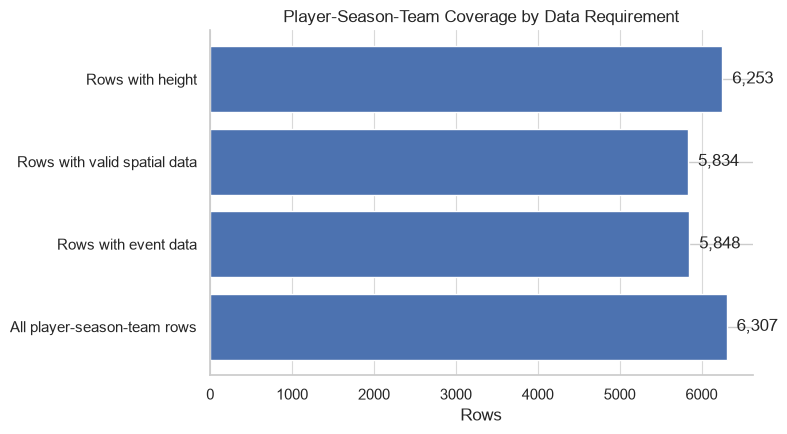

In [30]:
coverage_summary = pd.Series({
    "All player-season-team rows": len(features),
    "Rows with event data": int(features["has_event_data"].sum()),
    "Rows with valid spatial data": int(features["has_valid_spatial_data"].sum()),
    "Rows with height": int(features["height_cm"].notna().sum()),
})

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(coverage_summary.index, coverage_summary.values, color="#4C72B0")
ax.set_title("Player-Season-Team Coverage by Data Requirement")
ax.set_xlabel("Rows")
for i, v in enumerate(coverage_summary.values):
    ax.text(v, i, f"  {v:,}", va="center")
ax.grid(axis="x", color="0.85", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "feature_table_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

Almost every row (6,307 of 6,307) has season totals and per-36 rates, since those only need
`minutes` and `games_played` to be positive. Event coverage drops slightly to 5,848 rows, and
valid spatial coverage to 5,834, which matches the free-throw-only rows we found above.
Height is available for 6,253 of the 6,307 rows (the 27 missing players carry through as
missing `height_cm`, as intended).

Here is where things stand on missing values for the columns most likely to matter for
modeling later. None of these were filled in during this step.

In [31]:
candidate_missingness_cols = [
    "height_cm", "position", "mean_raw_shot_distance", "raw_shot_distance_std",
    "event_three_point_attempt_share", "three_point_attempt_share",
]
missingness = pd.DataFrame({
    "column": candidate_missingness_cols,
    "missing_count": [features[c].isna().sum() for c in candidate_missingness_cols],
    "missing_percentage": [round(100 * features[c].isna().mean(), 2) for c in candidate_missingness_cols],
})
missingness

,column,missing_count,missing_percentage
0,height_cm,54,0.86
1,position,172,2.73
2,mean_raw_shot_distance,473,7.50
3,raw_shot_distance_std,599,9.50
4,event_three_point_attempt_share,473,7.50
5,three_point_attempt_share,473,7.50


Height and position stay unfilled because we have not picked the eligible training sample
yet -- filling them now could bias that decision. The spatial and shooting-mix columns are
missing exactly where we would expect: players with no valid shot events, or no field-goal
attempts at all. Standard deviations based on a single shot are also left missing rather than
zero, since a spread cannot be computed from one point. None of this is imputed here; that
step belongs to the stage where we define the eligible training sample and its participation
thresholds.

We also wrote out a short data dictionary describing every column in the feature table, its
source, what a missing value means for that specific column, and a preliminary note on
whether it looks like a clustering candidate, a comparison-only field, or something we are
excluding for now.

In [32]:
def dict_row(column, group, source, definition, calculation, missing_meaning, intended_use,
             eligible, reason):
    return {"column": column, "group": group, "source": source, "definition": definition,
            "calculation": calculation, "missing_value_meaning": missing_meaning,
            "intended_use": intended_use, "eligible_for_clustering": eligible, "reason": reason}


dictionary_rows = []

for col in IDENTIFIER_COLS:
    dictionary_rows.append(dict_row(
        col, "identifier", "euroleague_players.csv", f"{col} identifier.", "as provided",
        "not applicable (identifier)", "join / lookup key", "exclude", "Identifier, not a statistic."))

dictionary_rows += [
    dict_row("height_cm", "descriptive", "players_bio.csv", "Player height in centimeters.",
             "as provided", "player's profile page could not be fully scraped",
             "candidate physical feature", "candidate",
             "Kept unfilled until the eligible sample and imputation stage are defined."),
    dict_row("position", "descriptive", "players_bio.csv", "Traditional position (Guard/Forward/Center).",
             "as provided", "player's profile page could not be fully scraped",
             "post-hoc comparison only", "comparison_only",
             "Never used as a clustering input; only for comparing clusters to positions afterwards."),
    dict_row("nationality", "descriptive", "players_bio.csv", "Player nationality.",
             "as provided", "profile page could not be fully scraped", "descriptive only",
             "exclude", "Demographic field, not a playing-style statistic."),
    dict_row("born", "descriptive", "players_bio.csv", "Date of birth.",
             "as provided", "profile page could not be fully scraped", "descriptive only",
             "undecided", "Could derive age-at-season later; not itself a style feature."),
]

for col in ["games_played", "games_started", "minutes"]:
    dictionary_rows.append(dict_row(
        col, "coverage", "euroleague_players.csv", f"Season total for {col.replace('_', ' ')}.",
        "as provided", "not applicable (always present)", "denominator / eligibility filter",
        "exclude", "Playing-time context, used as a denominator and filter, not a style feature."))

for col in ["has_positive_minutes", "has_positive_games", "has_event_data", "has_valid_spatial_data"]:
    dictionary_rows.append(dict_row(
        col, "coverage", "derived", f"Flag: {col.replace('_', ' ')}.", "boolean condition",
        "not applicable (always present)", "eligibility filter", "quality_flag",
        "Used to define the eligible training sample later, not itself a feature."))

for col in ["shot_event_count", "valid_spatial_shot_count", "valid_zone_shot_count"]:
    dictionary_rows.append(dict_row(
        col, "coverage", "euroleague_points.csv (aggregated)", f"Count of {col.replace('_', ' ')}.",
        "groupby size on the shot-attempt subset", "0 shots recorded for this player-season-team",
        "denominator / reliability check", "quality_flag",
        "Used to judge how much data the spatial statistics are based on."))

season_total_definitions = {
    "points": "Total points scored.", "two_points_made": "Made 2-point field goals.",
    "two_points_attempted": "Attempted 2-point field goals.",
    "two_points_percentage": "2-point shooting percentage.",
    "three_points_made": "Made 3-point field goals.",
    "three_points_attempted": "Attempted 3-point field goals.",
    "three_points_percentage": "3-point shooting percentage.",
    "free_throws_made": "Made free throws.", "free_throws_attempted": "Attempted free throws.",
    "free_throws_percentage": "Free-throw percentage.",
    "offensive_rebounds": "Offensive rebounds.", "defensive_rebounds": "Defensive rebounds.",
    "total_rebounds": "Total rebounds.", "assists": "Assists.", "steals": "Steals.",
    "turnovers": "Turnovers.", "blocks_favour": "Blocks made by the player.",
    "blocks_against": "Times the player was blocked.", "fouls_committed": "Personal fouls committed.",
    "fouls_received": "Fouls drawn.",
}
for col, definition in season_total_definitions.items():
    dictionary_rows.append(dict_row(
        col, "season_totals", "euroleague_players.csv", definition, "as provided",
        "not applicable (always present)", "candidate volume/efficiency statistic",
        "candidate", "Season total from the source file."))

for per_36_col, total_col in PER_36_SOURCE_COLUMNS.items():
    dictionary_rows.append(dict_row(
        per_36_col, "season_totals", "derived",
        f"{total_col.replace('_', ' ').capitalize()} per 36 minutes played.",
        f"{total_col} / minutes * 36, only where minutes > 0", "minutes == 0 for this row",
        "candidate playing-style rate feature", "candidate",
        "Calculated from totals because the provided minutes_per_game did not match "
        "minutes / games_played in 462 rows."))

shooting_mix_definitions = {
    "field_goal_attempts": ("Two-point plus three-point attempts (season totals).",
                             "two_points_attempted + three_points_attempted", "not applicable"),
    "two_point_attempt_share": ("Share of field-goal attempts that were two-pointers.",
                                 "two_points_attempted / field_goal_attempts", "field_goal_attempts == 0"),
    "three_point_attempt_share": ("Share of field-goal attempts that were three-pointers.",
                                   "three_points_attempted / field_goal_attempts", "field_goal_attempts == 0"),
    "free_throw_attempt_rate": ("Free-throw attempts relative to field-goal attempts.",
                                 "free_throws_attempted / field_goal_attempts", "field_goal_attempts == 0"),
    "event_two_point_attempt_share": ("Share of recorded shot events that were two-point attempts.",
                                       "two_point_event_count / shot_event_count", "shot_event_count == 0"),
    "event_three_point_attempt_share": ("Share of recorded shot events that were three-point attempts.",
                                         "three_point_event_count / shot_event_count", "shot_event_count == 0"),
}
for col, (definition, calc, missing_meaning) in shooting_mix_definitions.items():
    dictionary_rows.append(dict_row(
        col, "shooting_mix", "derived", definition, calc, missing_meaning,
        "candidate shot-selection feature", "candidate",
        "Undefined shares are left as NaN, not filled with zero or an average."))

spatial_definitions = {
    "mean_lateral_shot_position": "Mean coord_x across valid field-goal attempts.",
    "lateral_shot_position_std": "Standard deviation of coord_x across valid field-goal attempts.",
    "mean_longitudinal_shot_position": "Mean coord_y across valid field-goal attempts.",
    "longitudinal_shot_position_std": "Standard deviation of coord_y across valid field-goal attempts.",
    "mean_raw_shot_distance": "Mean distance from (0, 0) across valid field-goal attempts, raw coordinate units.",
    "median_raw_shot_distance": "Median distance from (0, 0) across valid field-goal attempts, raw coordinate units.",
    "raw_shot_distance_std": "Standard deviation of distance from (0, 0), raw coordinate units.",
}
for col, definition in spatial_definitions.items():
    dictionary_rows.append(dict_row(
        col, "spatial", "euroleague_points.csv (aggregated)", definition,
        "computed on valid_spatial_shot_count field-goal attempts, basket at (0, 0)",
        "no valid spatial shots for this player-season-team, or only one shot (std only)",
        "candidate shot-location feature", "candidate",
        "Basket location and raw-unit distance are empirical estimates, not documented facts; "
        "see the coordinate discussion above."))

for col in zone_share_cols:
    zone_letter = col.split("_")[1].upper()
    dictionary_rows.append(dict_row(
        col, "spatial", "euroleague_points.csv (aggregated)",
        f"Share of valid field-goal attempts recorded in zone {zone_letter}.",
        f"count in zone {zone_letter} / valid_zone_shot_count", "no valid spatial shots for this player-season-team",
        "candidate shot-location feature", "candidate",
        "Zone boundaries are not documented; the letter is used as recorded, without an assumed name."))

for col in EXCLUDED_DESCRIPTIVE_COLS:
    dictionary_rows.append(dict_row(
        col, "excluded_descriptive", "euroleague_players.csv",
        f"Season total for {col.replace('_', ' ')}.", "as provided",
        "not applicable (always present)", "descriptive reference only", "exclude",
        "Mixes playing quality with playing style; not used as a clustering feature."))

feature_dictionary = pd.DataFrame(dictionary_rows)
dictionary_path = REPO_ROOT / "outputs" / "tables" / "player_season_team_feature_dictionary.csv"
feature_dictionary.to_csv(dictionary_path, index=False)
print(f"Saved: {dictionary_path.relative_to(REPO_ROOT)} ({len(feature_dictionary)} columns documented)")
print(f"Feature table columns: {features.shape[1]}, dictionary rows: {len(feature_dictionary)}")

Saved: outputs\tables\player_season_team_feature_dictionary.csv (76 columns documented)
Feature table columns: 76, dictionary rows: 76


The complete table has one row per player, season, and team, with season totals and per-36
rates, shot-selection shares, and shot-location statistics sitting alongside the identifiers
and biography fields. Height, position, and every spatial feature keep their missing values
exactly where the underlying data is missing, since we still need to define which
player-season-team rows are eligible for training before deciding how -- or whether -- to
fill anything in.